# Hierarchical Clustering

Hierarchical Clustering is an unsupervised machine learning algorithm used to group similar data points into clusters.

Unlike K-Means, Hierarchical Clustering does not require us to specify the number of clusters at the beginning.

Instead, it builds a hierarchy of clusters and represents this hierarchy using a tree-like diagram called a **dendrogram**.

In this notebook, we will learn:

- What Hierarchical Clustering is
- Agglomerative and Divisive clustering
- How Agglomerative Clustering works
- What a dendrogram is
- Different linkage methods
- Distance metrics
- How to choose the number of clusters
- How to implement Hierarchical Clustering using Scikit-learn
- How to visualize the resulting clusters
- How Hierarchical Clustering differs from K-Means

## What is Hierarchical Clustering?

Hierarchical Clustering is a clustering technique that creates a hierarchy of groups.

The algorithm starts with either:

- Each observation as an individual cluster and repeatedly merges clusters, or
- One large cluster and repeatedly splits it.

This produces a hierarchy that can be visualized using a **dendrogram**.

The hierarchy allows us to examine the clustering structure at different levels.

### Main idea

Instead of directly saying:

> "Create exactly 3 clusters."

Hierarchical Clustering asks:

> "How are the observations related to one another at different levels of similarity?"

This makes Hierarchical Clustering particularly useful when we want to understand the structure of the data.

## Types of Hierarchical Clustering

There are two main approaches to Hierarchical Clustering:

### 1. Agglomerative Clustering

Agglomerative clustering follows a **bottom-up** approach.

Initially:

- Every observation is treated as its own cluster.

Then:

- The two closest clusters are merged.
- The process continues until all observations belong to one cluster.

This is the most commonly used form of Hierarchical Clustering.

### 2. Divisive Clustering

Divisive clustering follows a **top-down** approach.

Initially:

- All observations belong to one large cluster.

Then:

- The cluster is repeatedly divided into smaller clusters.

Divisive clustering is less commonly used in practical machine learning applications.

### In this notebook

We will mainly focus on:

**Agglomerative Hierarchical Clustering**

## Agglomerative Hierarchical Clustering

Agglomerative Clustering starts by treating every data point as a separate cluster.

Suppose we have five observations:

    A   B   C   D   E

Initially:

    {A}, {B}, {C}, {D}, {E}

The algorithm finds the two closest clusters and merges them.

For example:

    {A,B}, {C}, {D}, {E}

Then another pair is merged:

    {A,B}, {C,D}, {E}

The process continues:

    {A,B,C,D}, {E}

Finally:

    {A,B,C,D,E}

The complete sequence of merges forms a hierarchical structure.

### General process

1. Start with one cluster per observation.
2. Calculate distances between clusters.
3. Find the closest two clusters.
4. Merge them.
5. Recalculate the distances.
6. Repeat until only one cluster remains.

The definition of "closest clusters" depends on the **linkage method**.

## Simple Example

Consider four one-dimensional observations:

    1, 2, 8, 9

Initially:

    {1}, {2}, {8}, {9}

The closest observations are:

    1 and 2

So they are merged:

    {1,2}, {8}, {9}

Next:

    8 and 9

are merged:

    {1,2}, {8,9}

Finally, the two remaining clusters are merged:

    {1,2,8,9}

The hierarchy can be represented as:

              {1,2,8,9}
                /    \
            {1,2}   {8,9}
             / \     / \
            1   2   8   9

A dendrogram provides a visual representation of this process.

## Dendrogram

A **dendrogram** is a tree-like diagram that represents the hierarchy produced by hierarchical clustering.

It shows:

- Which observations were merged
- The order in which they were merged
- The distance at which they were merged

### Important idea

The vertical axis represents the **linkage distance**.

A merge occurring at a low height means the two clusters were relatively similar.

A merge occurring at a high height means the two clusters were relatively different.

### Cutting the dendrogram

We can draw a horizontal line across the dendrogram.

The number of branches intersected by that line determines the number of clusters.

Therefore, a dendrogram can help us choose a suitable number of clusters without specifying it before fitting the hierarchy.

## Linkage Methods

When we have two clusters, we need a rule to determine the distance between them.

This rule is called the **linkage method**.

Common linkage methods are:

1. Single Linkage
2. Complete Linkage
3. Average Linkage
4. Ward Linkage

The choice of linkage method can significantly affect the resulting clusters.

## Single Linkage

Single linkage defines the distance between two clusters as the distance between their **closest pair of observations**.

Mathematically:

$$
D(A,B) = \min_{x \in A,\;y \in B} d(x,y)
$$

where:

- $A$ = first cluster
- $B$ = second cluster
- $d(x,y)$ = distance between observations $x$ and $y$

### Intuition

The clusters are considered close if at least one pair of points is close.

### Advantage

Single linkage can identify elongated or irregularly shaped clusters.

### Disadvantage

It can suffer from the **chaining effect**, where clusters become connected through individual nearby observations.

## Complete Linkage

Complete linkage defines the distance between two clusters using the **farthest pair of observations**.

Mathematically:

$$
D(A,B) = \max_{x \in A,\;y \in B} d(x,y)
$$

### Intuition

Two clusters are considered close only when all of their observations are reasonably close.

### Advantage

It generally produces compact and well-separated clusters.

### Disadvantage

It can be sensitive to outliers because the farthest observations determine the cluster distance.

## Average Linkage

Average linkage defines the distance between two clusters as the average distance between all pairs of observations from the two clusters.

Mathematically:

$$
D(A,B)
=
\frac{1}{|A||B|}
\sum_{x \in A}
\sum_{y \in B}
d(x,y)
$$

### Intuition

Instead of looking only at the closest or farthest points, average linkage considers all pairwise distances.

### Advantage

It provides a compromise between single and complete linkage.

### Disadvantage

It can be computationally more expensive than some simpler approaches.

## Ward Linkage

Ward linkage merges clusters in a way that minimizes the increase in **within-cluster variance**.

The goal is to create clusters that are internally compact.

Conceptually, Ward's method chooses the merge that produces the smallest increase in total within-cluster sum of squares.

For a cluster $C$, the within-cluster sum of squares can be written as:

$$
W(C)
=
\sum_{x_i \in C}
\|x_i-\mu_C\|^2
$$

where:

- $x_i$ = observation
- $\mu_C$ = centroid of cluster $C$

### Important

Ward linkage generally works with Euclidean distance and tends to produce compact, roughly spherical clusters.

It is often a strong default choice when the data is numerical and appropriately scaled.

## Distance Metrics

Hierarchical Clustering depends heavily on the concept of distance.

A common distance measure is **Euclidean distance**.

For two observations:

$$
x=(x_1,x_2,\dots,x_p)
$$

and

$$
y=(y_1,y_2,\dots,y_p)
$$

Euclidean distance is:

$$
d(x,y)
=
\sqrt{
\sum_{j=1}^{p}(x_j-y_j)^2
}
$$

For two-dimensional data:

$$
d(x,y)
=
\sqrt{
(x_1-y_1)^2+(x_2-y_2)^2
}
$$

Other possible distance metrics include:

- Manhattan distance
- Cosine distance
- Minkowski distance
- Euclidean distance

The appropriate metric depends on the nature of the data.

## Why Feature Scaling Matters

Distance-based algorithms are sensitive to the scale of features.

Suppose we have:

- Age: 18–80
- Income: 20,000–2,000,000

Income has a much larger numerical scale than age.

Without scaling, income may dominate the distance calculation.

Therefore, feature scaling is often important before applying Hierarchical Clustering.

A common approach is Standardization:

$$
z = \frac{x-\mu}{\sigma}
$$

where:

- $\mu$ = feature mean
- $\sigma$ = feature standard deviation

After standardization:

- Mean ≈ 0
- Standard deviation ≈ 1

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

## Creating a Dataset

We will first create a synthetic dataset containing several natural groups.

Using synthetic data allows us to clearly visualize how Hierarchical Clustering works.

In [2]:
X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

X.shape

(300, 2)

## Convert Dataset to DataFrame

In [3]:
df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

df.head()

,Feature_1,Feature_2
0,-9.205816,6.643647
1,-9.526658,7.015878
2,-1.851162,8.037611
3,-7.053772,-6.001088
4,-10.468827,6.517054


## Visualizing the Dataset

Before applying clustering, we will visualize the observations.

Because our dataset has two features, we can directly plot the observations in a two-dimensional space.

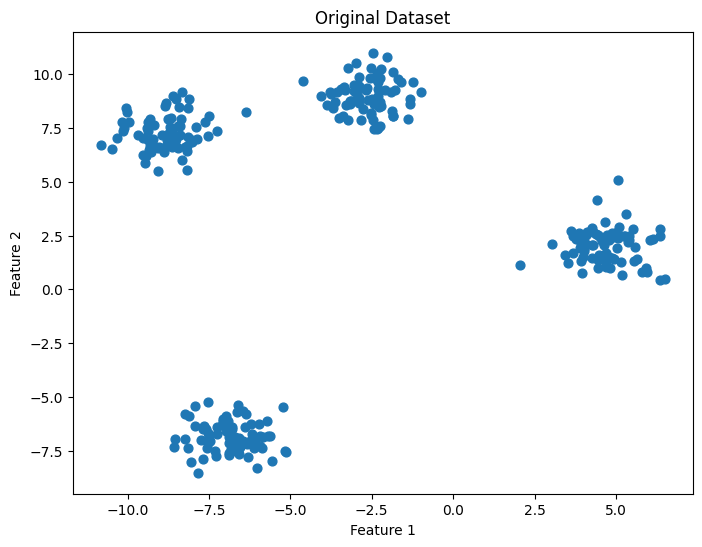

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=40
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Dataset")

plt.show()

## Standardize the Data

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.10650115,  0.6123425 ],
       [-1.16767443,  0.67239056],
       [ 0.29577292,  0.83721579],
       [-0.69618197, -1.4274976 ],
       [-1.34731292,  0.59192052]])

## Creating the Linkage Matrix

The `linkage()` function from SciPy performs the hierarchical merging process.

The resulting linkage matrix stores information about:

- Which clusters were merged
- The distance at which they were merged
- The number of observations in the newly formed cluster

We will use the Ward linkage method first.

In [7]:
Z = linkage(
    X_scaled,
    method="ward"
)

Z.shape

(299, 4)

Because there are 300 observations, hierarchical clustering requires:

$$ n-1 = 299 $$

merges to combine all observations into one cluster.

## Understanding the Linkage Matrix

In [8]:
Z[:5]

array([[4.80000000e+01, 2.84000000e+02, 4.60827188e-04, 2.00000000e+00],
       [2.00000000e+00, 1.69000000e+02, 1.88906908e-03, 2.00000000e+00],
       [2.14000000e+02, 2.62000000e+02, 5.88946771e-03, 2.00000000e+00],
       [1.08000000e+02, 2.54000000e+02, 7.68969199e-03, 2.00000000e+00],
       [1.20000000e+01, 1.05000000e+02, 7.83140908e-03, 2.00000000e+00]])

### Linkage Matrix Columns

The linkage matrix contains four columns:

| Column | Meaning |
|---|---|
| Column 1 | First cluster being merged |
| Column 2 | Second cluster being merged |
| Column 3 | Distance between the clusters |
| Column 4 | Number of observations in the newly formed cluster |

This matrix contains the complete hierarchical clustering structure.

## Building the Dendrogram

Now we can visualize the hierarchical structure using a dendrogram.

The dendrogram shows the sequence of merges performed by the hierarchical clustering algorithm.

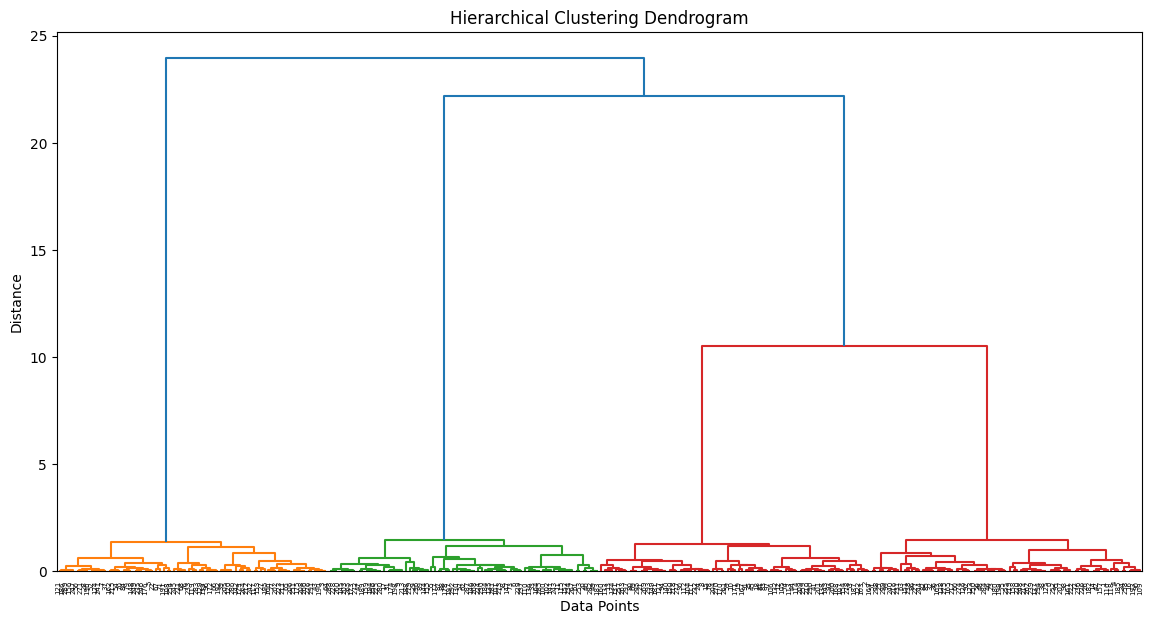

In [9]:
plt.figure(figsize=(14, 7))

dendrogram(Z)

plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

## Simplified Dendrogram

When a dataset contains many observations, the complete dendrogram can become difficult to read.

We can display only the last few merging levels using a truncated dendrogram.

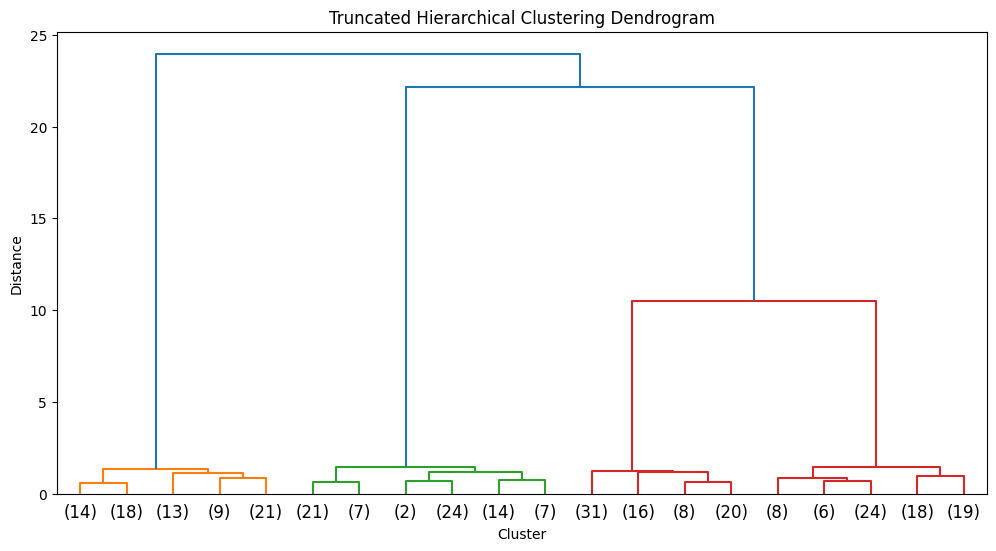

In [10]:
plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
)

plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.title("Truncated Hierarchical Clustering Dendrogram")

plt.show()

## Choosing the Number of Clusters

One of the main advantages of Hierarchical Clustering is that we can inspect the dendrogram before deciding how many clusters to use.

Suppose we draw a horizontal line across the dendrogram.

The number of vertical branches crossed by that line represents the number of clusters.

### Example

If a horizontal cut intersects:

- 2 branches → 2 clusters
- 3 branches → 3 clusters
- 4 branches → 4 clusters

Therefore, the dendrogram can help us make an informed choice about the number of clusters.

## Applying Agglomerative Clustering

From the dendrogram, suppose we decide that four clusters provide a meaningful partition.

We can now use Scikit-learn's `AgglomerativeClustering`.

We will use:

- `n_clusters = 4`
- `linkage = "ward"`

In [11]:
model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

labels = model.fit_predict(X_scaled)

labels[:10]

array([0, 0, 3, 1, 0, 1, 2, 1, 3, 2])

## Check Cluster Labels

In [12]:
np.unique(labels)

array([0, 1, 2, 3])

## Count Observations in Each Cluster

In [13]:
cluster_counts = pd.Series(labels).value_counts().sort_index()

cluster_counts

0    75
1    75
2    75
3    75
Name: count, dtype: int64

## Visualizing the Clusters

We can now visualize the cluster assignments.

Each observation has been assigned a cluster label by Agglomerative Clustering.

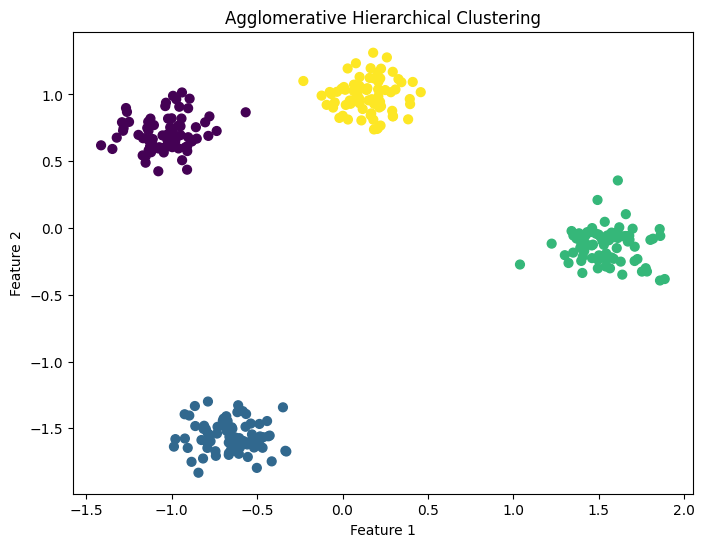

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    s=40
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Hierarchical Clustering")

plt.show()

## Comparing Linkage Methods

Different linkage methods can produce different clustering structures.

We will compare:

- Single linkage
- Complete linkage
- Average linkage
- Ward linkage

This helps us understand why the linkage method is an important hyperparameter.

## Single Linkage

In [15]:
model_single = AgglomerativeClustering(
    n_clusters=4,
    linkage="single"
)

labels_single = model_single.fit_predict(X_scaled)

## Complete Linkage

In [16]:
model_complete = AgglomerativeClustering(
    n_clusters=4,
    linkage="complete"
)

labels_complete = model_complete.fit_predict(X_scaled)

## Average Linkage

In [17]:
model_average = AgglomerativeClustering(
    n_clusters=4,
    linkage="average"
)

labels_average = model_average.fit_predict(X_scaled)

## Ward Linkage

In [18]:
model_ward = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

labels_ward = model_ward.fit_predict(X_scaled)

## Visualize Single Linkage

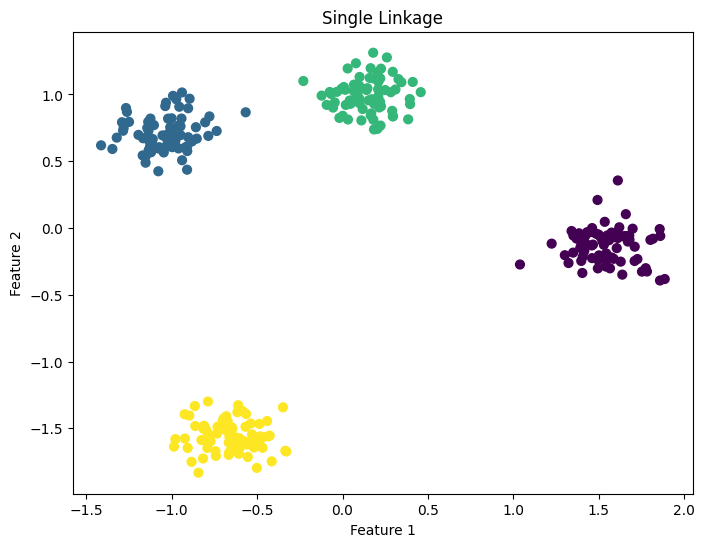

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels_single,
    s=40
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Single Linkage")

plt.show()

## Visualize Complete Linkage

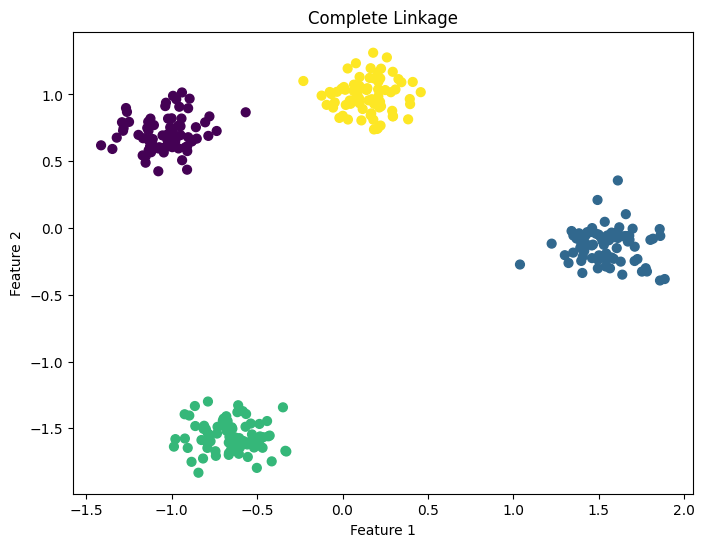

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels_complete,
    s=40
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Complete Linkage")

plt.show()

## Visualize Average Linkage

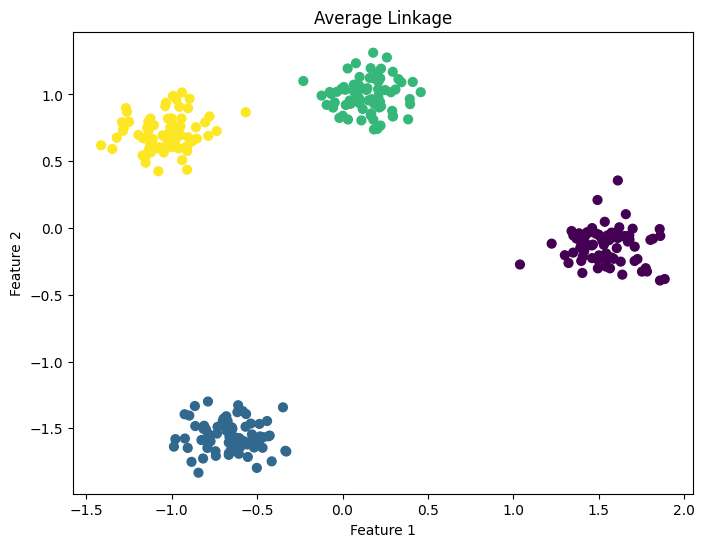

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels_average,
    s=40
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Average Linkage")

plt.show()

## Visualize Ward Linkage

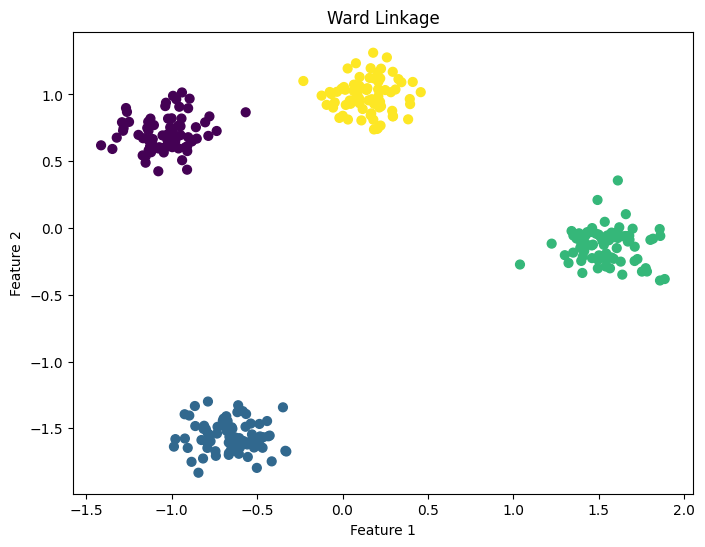

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels_ward,
    s=40
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Ward Linkage")

plt.show()

## Comparing Dendrograms

We can also compare the hierarchical structures produced by different linkage methods.

This helps us see how the definition of cluster distance affects the hierarchy.

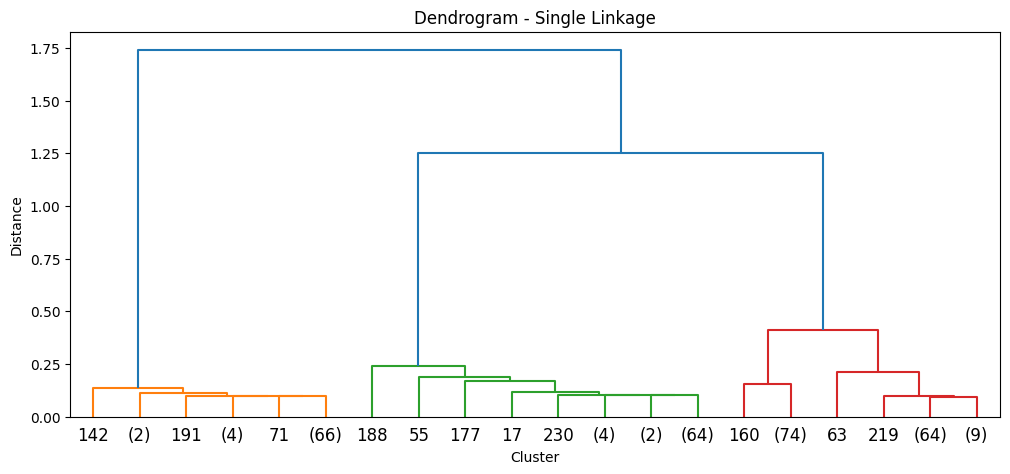

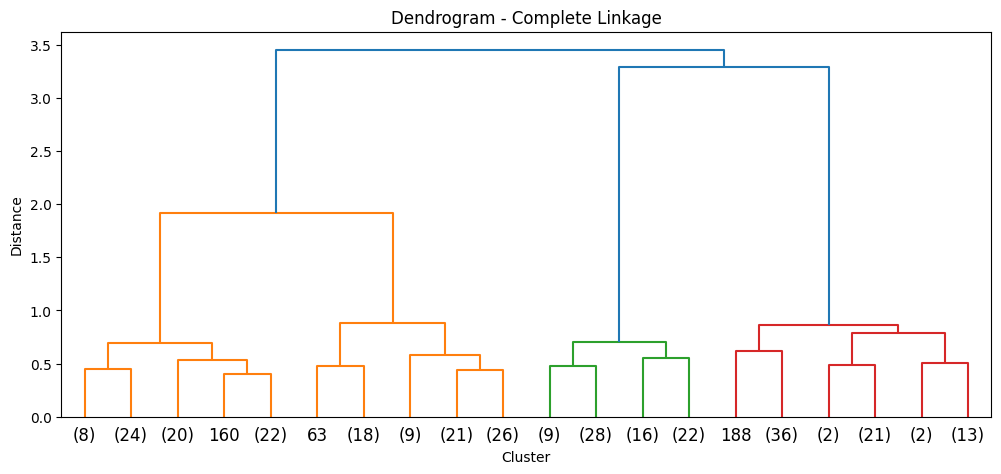

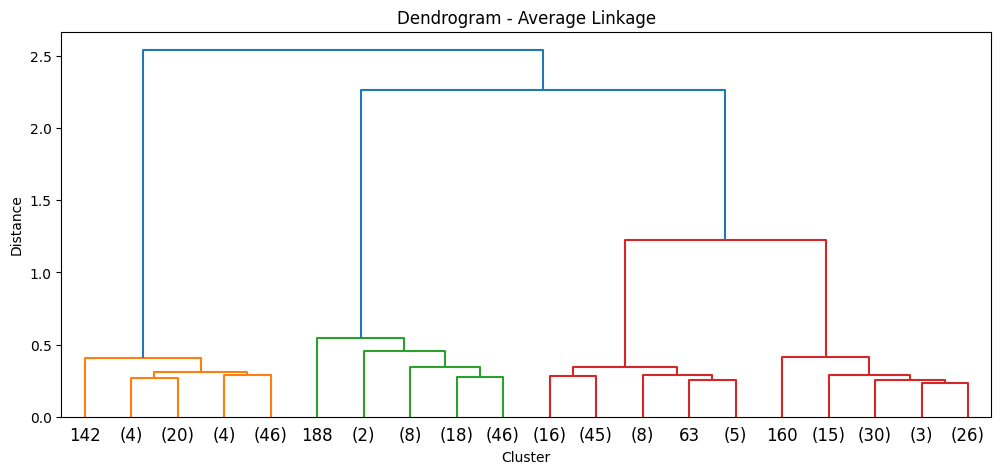

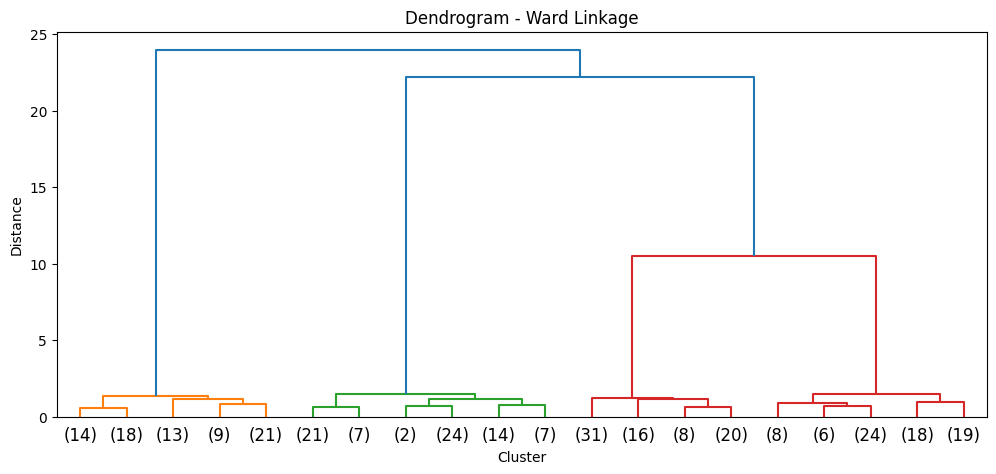

In [23]:
methods = ["single", "complete", "average", "ward"]

for method in methods:
    Z_method = linkage(
        X_scaled,
        method=method
    )

    plt.figure(figsize=(12, 5))

    dendrogram(
        Z_method,
        truncate_mode="lastp",
        p=20
    )

    plt.xlabel("Cluster")
    plt.ylabel("Distance")
    plt.title(f"Dendrogram - {method.title()} Linkage")

    plt.show()

## Effect of the Number of Clusters

The number of clusters is an important parameter.

Although the hierarchical tree is constructed independently of the final number of clusters, we can choose a different number of clusters by changing where we cut the hierarchy.

Let's compare:

- 2 clusters
- 3 clusters
- 4 clusters
- 5 clusters

## 2 Clusters

In [24]:
model_2 = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

labels_2 = model_2.fit_predict(X_scaled)

## 3 Clusters

In [25]:
model_3 = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels_3 = model_3.fit_predict(X_scaled)

## 5 Clusters

In [26]:
model_5 = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

labels_5 = model_5.fit_predict(X_scaled)

## Visualizing Different Cluster Counts

Changing `n_clusters` changes the level at which the hierarchical tree is cut.

This allows us to obtain different levels of grouping from the same hierarchical structure.

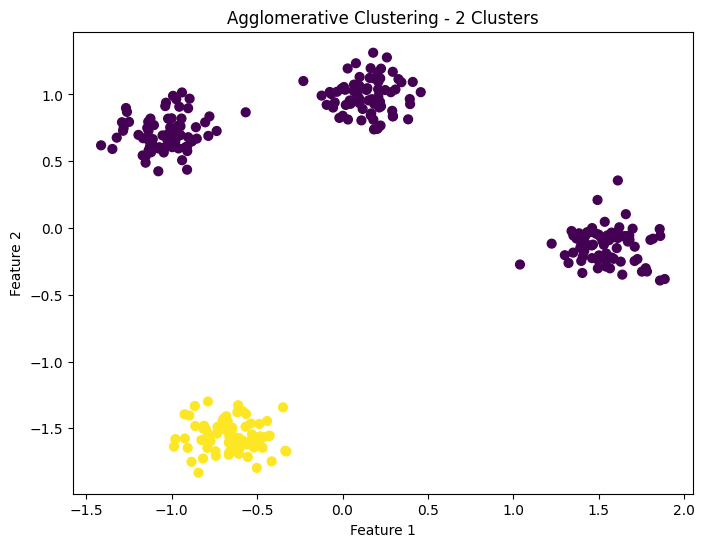

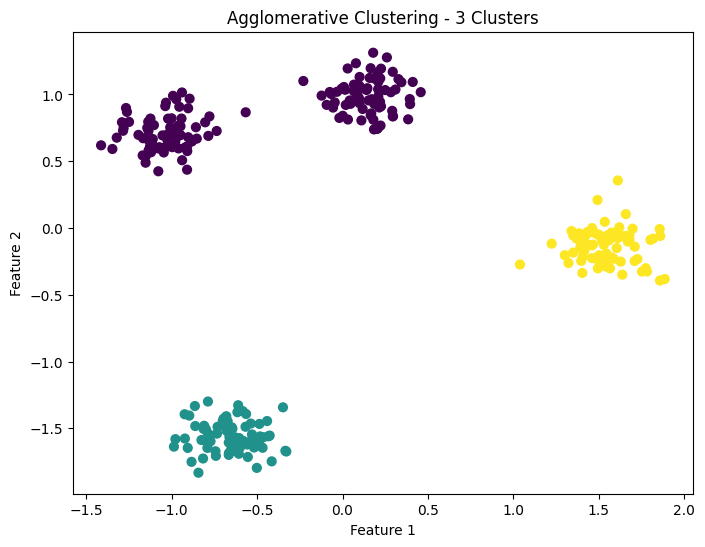

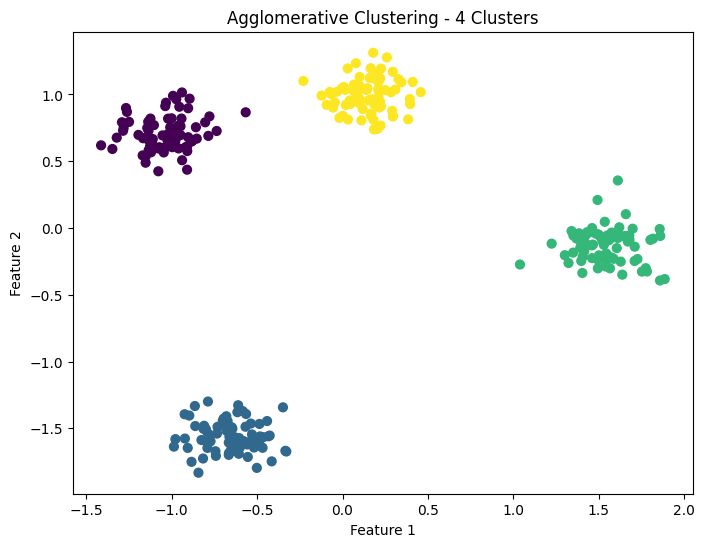

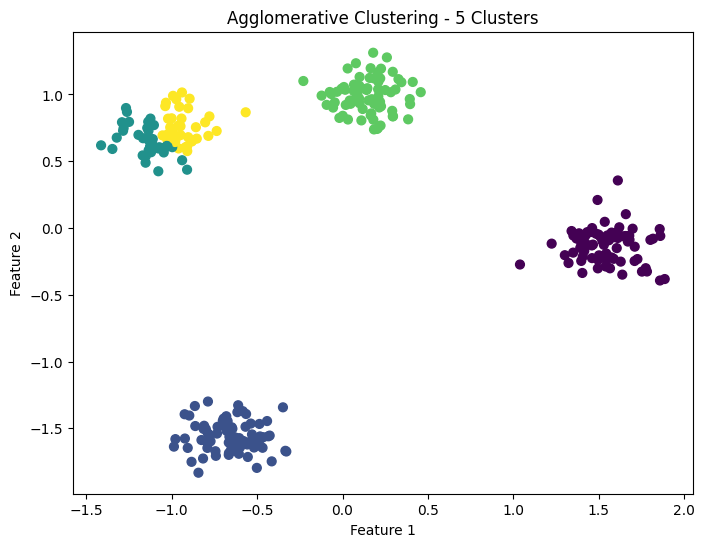

In [27]:
cluster_results = {
    2: labels_2,
    3: labels_3,
    4: labels_ward,
    5: labels_5
}

for n_clusters, cluster_labels in cluster_results.items():

    plt.figure(figsize=(8, 6))

    plt.scatter(
        X_scaled[:, 0],
        X_scaled[:, 1],
        c=cluster_labels,
        s=40
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(
        f"Agglomerative Clustering - "
        f"{n_clusters} Clusters"
    )

    plt.show()

# Hierarchical Clustering on a Real Dataset

Now that we understand the algorithm using synthetic data, we will apply Hierarchical Clustering to a real dataset.

We will use the **Iris dataset**.

The Iris dataset contains measurements of flowers using four numerical features:

- Sepal length
- Sepal width
- Petal length
- Petal width

The target labels will not be used during clustering because Hierarchical Clustering is an unsupervised learning algorithm.

## Load Iris Dataset

In [28]:
from sklearn.datasets import load_iris

iris = load_iris()

X_iris = iris.data
y_iris = iris.target

X_iris.shape

(150, 4)

## Create Iris DataFrame

In [29]:
iris_df = pd.DataFrame(
    X_iris,
    columns=iris.feature_names
)

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Standardizing the Iris Features

The four features have different numerical ranges.

Because Hierarchical Clustering is distance-based, we standardize the features before clustering.

In [30]:
iris_scaler = StandardScaler()

X_iris_scaled = iris_scaler.fit_transform(X_iris)

X_iris_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

## Create Iris Dendrogram

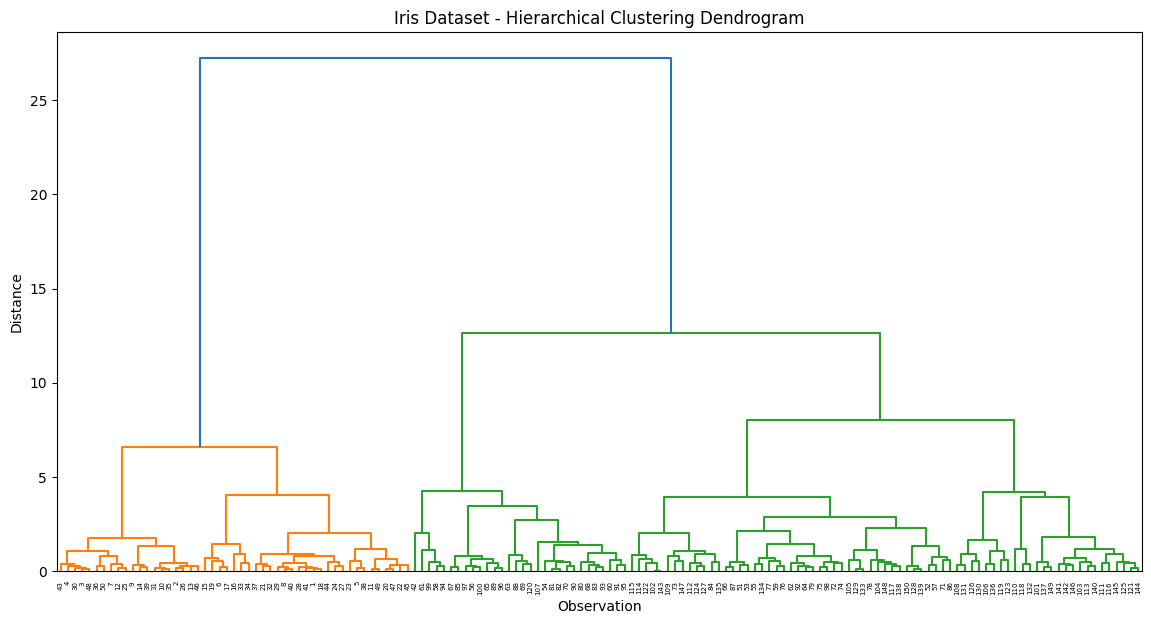

In [31]:
Z_iris = linkage(
    X_iris_scaled,
    method="ward"
)

plt.figure(figsize=(14, 7))

dendrogram(
    Z_iris,
    labels=np.arange(1, 151)
)

plt.xlabel("Observation")
plt.ylabel("Distance")
plt.title("Iris Dataset - Hierarchical Clustering Dendrogram")

plt.show()

## Apply Hierarchical Clustering to Iris

In [32]:
iris_model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

iris_labels = iris_model.fit_predict(X_iris_scaled)

iris_labels[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## Add Cluster Labels

In [33]:
iris_clustered = iris_df.copy()

iris_clustered["Cluster"] = iris_labels

iris_clustered.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


## Analyze Cluster Sizes

In [34]:
iris_clustered["Cluster"].value_counts().sort_index()

Cluster
0    71
1    49
2    30
Name: count, dtype: int64

## Visualizing Iris Clusters

The Iris dataset contains four features, so we cannot directly visualize all dimensions simultaneously.

For visualization, we will use:

- Petal length
- Petal width

The clustering itself, however, was performed using all four standardized features.

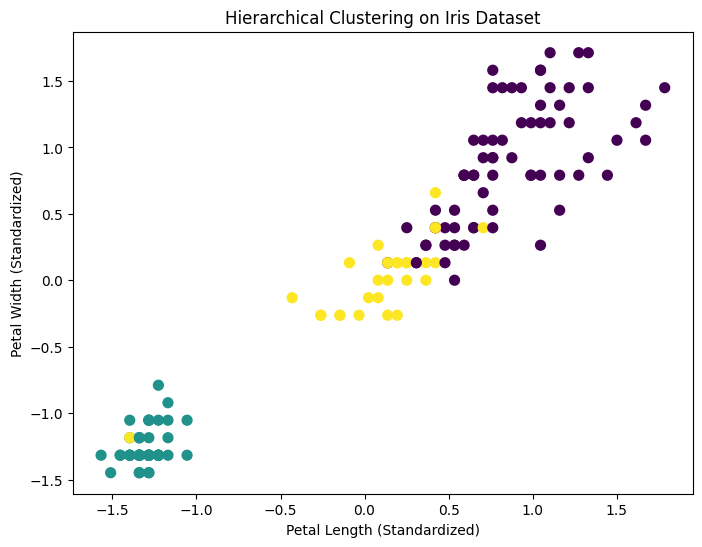

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_iris_scaled[:, 2],
    X_iris_scaled[:, 3],
    c=iris_labels,
    s=50
)

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Hierarchical Clustering on Iris Dataset")

plt.show()

## Important Parameters in AgglomerativeClustering

The main parameters include:

### `n_clusters`

Number of clusters to create.

Example:


In [36]:
AgglomerativeClustering(
    n_clusters=4
)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",4
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


linkage

Determines how the distance between clusters is calculated.

Common choices:

    "ward"
    "complete"
    "average"
    "single"
    metric

Determines the distance metric used by the algorithm.

Examples include:

    euclidean
    manhattan
    cosine

However, the available combinations depend on the selected linkage method.

For example, Ward linkage requires Euclidean distance.


---


## Advantages of Hierarchical Clustering

### 1. No need to choose the number of clusters initially

The hierarchy can be built first and the number of clusters can be selected later.

### 2. Dendrogram provides useful visualization

The dendrogram makes the hierarchical structure of the data easier to inspect.

### 3. Can capture different cluster structures

Different linkage methods allow the algorithm to identify different types of relationships.

### 4. Useful for exploratory analysis

Hierarchical clustering is especially useful when we want to understand relationships between observations.

### 5. No explicit centroid initialization

Unlike K-Means, hierarchical clustering does not require randomly initialized centroids.

## Disadvantages of Hierarchical Clustering

### 1. Computationally expensive

Hierarchical clustering can become expensive for very large datasets.

### 2. Sensitive to distance and linkage choices

Different distance metrics and linkage methods can produce different results.

### 3. Sensitive to scaling

Features with larger numerical scales can dominate distance calculations.

### 4. Merges are generally irreversible

Once two clusters are merged, the standard agglomerative procedure does not normally undo that decision.

### 5. Can be sensitive to outliers

Outliers can affect distances and therefore influence the hierarchical structure.

## K-Means vs Hierarchical Clustering

| Feature | K-Means | Hierarchical Clustering |
|---|---|---|
| Learning type | Unsupervised | Unsupervised |
| Requires number of clusters | Yes | Can be selected after hierarchy |
| Uses centroids | Yes | No |
| Produces hierarchy | No | Yes |
| Dendrogram | No | Yes |
| Initialization | Centroid initialization | Starts with individual clusters |
| Scalability | Generally better | Generally worse |
| Sensitive to scaling | Yes | Yes |
| Cluster shape | Often compact/spherical | Depends on linkage |
| Main hyperparameters | `n_clusters` | `n_clusters`, `linkage`, `metric` |

### Key difference

K-Means directly searches for a specified number of clusters.

Hierarchical Clustering builds a hierarchy of clusters and allows us to examine that hierarchy at different levels.

## When Should We Use Hierarchical Clustering?

Hierarchical Clustering is particularly useful when:

- The dataset is not extremely large.
- We want to understand the hierarchy of relationships.
- We do not know the appropriate number of clusters initially.
- A dendrogram would help with exploratory analysis.
- We want to compare different grouping levels.
- We are interested in relationships between observations.

For very large datasets, methods such as K-Means may be more computationally practical.

# Key Takeaways

1. Hierarchical Clustering is an unsupervised learning algorithm.

2. Agglomerative Clustering uses a bottom-up approach.

3. Initially, every observation is treated as its own cluster.

4. Similar clusters are repeatedly merged.

5. The complete hierarchy can be represented using a dendrogram.

6. The dendrogram can help us choose the number of clusters.

7. Linkage determines how the distance between clusters is calculated.

8. Important linkage methods include:
   - Single
   - Complete
   - Average
   - Ward

9. Distance-based clustering is sensitive to feature scaling.

10. Ward linkage generally creates compact clusters and is commonly useful for standardized numerical data.

11. Hierarchical Clustering is useful for exploratory analysis and understanding the structure of data.

12. Compared with K-Means, Hierarchical Clustering provides a hierarchy but can be more computationally expensive for large datasets.

# Final Conceptual Summary

The core idea of Agglomerative Hierarchical Clustering can be summarized as:

$$
\boxed{
\text{Start with individual points}
\rightarrow
\text{Find closest clusters}
\rightarrow
\text{Merge}
\rightarrow
\text{Repeat}
}
$$

The resulting hierarchy is represented by a dendrogram.

The dendrogram allows us to decide where to cut the hierarchy:

$$
\text{Dendrogram}
\rightarrow
\text{Choose Cut Level}
\rightarrow
\text{Obtain Clusters}
$$

The final clustering depends strongly on:

$$
\boxed{
\text{Distance Metric}
+
\text{Linkage Method}
+
\text{Cut Level}
}
$$

Therefore, understanding the distance metric and linkage method is essential when applying Hierarchical Clustering.